# Pairwise fuzzy-deduplication benchmark

This notebook evaluates eight NeMo Curator fuzzy-deduplication configurations on the same 466 LLM-annotated MCQA pairs. Both the annotator and the detector observe the complete item: question plus ordered, labeled choices. The correct answer and all historical sampling metadata are excluded. Each pair is evaluated independently, so connected-component chaining cannot affect its prediction.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
import math
import os
import platform
import shutil
import subprocess
from datetime import datetime, timezone
from itertools import combinations
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import binomtest
from sklearn.metrics import matthews_corrcoef

from mmlu_pt.mcqa_minimal import normalize_question_for_dedup

RUN_EXPERIMENTS = False
NUM_HASHES = 260
EXPECTED_PAIRS = 466
EXPECTED_UNIQUE_ITEMS = 837
EXPECTED_ANNOTATION_SHA256 = "a51cbf1099b969b0573abd104184bf91874df64f1dc09bbb5a418ac2110290a6"
VALID_LABELS = {"duplicate", "related_but_distinct", "distinct", "unsure"}
DECISIVE_LABELS = {"duplicate", "related_but_distinct", "distinct"}
REQUIRED_COLUMNS = ("pair_key", "left_question", "left_choices", "right_question", "right_choices", "label")

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def detect_gpu() -> tuple[bool, str]:
    executable = shutil.which("nvidia-smi")
    if executable is None:
        return False, "nvidia-smi is not installed"
    completed = subprocess.run(
        [executable, "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
        capture_output=True, text=True, check=False, timeout=15,
    )
    description = completed.stdout.strip() or completed.stderr.strip()
    return completed.returncode == 0 and bool(completed.stdout.strip()), description

REPO_ROOT = find_repo_root(Path.cwd())
ANNOTATION_PATH = REPO_ROOT / "assets" / "annotations" / "manual_labels_llm_annotated.csv"
ARTIFACT_BASE = REPO_ROOT / "output" / "fuzzy-deduplication-pairwise-benchmark"
GPU_AVAILABLE, GPU_DESCRIPTION = detect_gpu()

print(f"Repository: {REPO_ROOT}")
print(f"Annotations: {ANNOTATION_PATH}")
print(f"Python: {platform.python_version()}")
print(f"NeMo Curator: {importlib.metadata.version('nemo-curator')}")
print(f"GPU available: {GPU_AVAILABLE} ({GPU_DESCRIPTION})")

Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Annotations: /home/aluno_paulosantana/repositories/mmlu-pt/assets/annotations/manual_labels_llm_annotated.csv
Python: 3.12.3
NeMo Curator: 1.3.0
GPU available: True (NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04)


## 1. Fixed labeled benchmark

The source CSV is read with an explicit six-column projection. Historical run IDs, source exams, answers, stored similarities, components, and sampled-for-configuration fields cannot enter the evaluation. LLM labels are used as an operational reference: the separate human–LLM agreement study found 47/47 agreement for the binary duplicate decision and Cohen's kappa of 1.0 on its human-reviewed subset.

In [2]:
if not ANNOTATION_PATH.is_file():
    raise FileNotFoundError(ANNOTATION_PATH)
annotation_sha256 = file_sha256(ANNOTATION_PATH)
if annotation_sha256 != EXPECTED_ANNOTATION_SHA256:
    raise ValueError(f"Annotation integrity check failed: {annotation_sha256}")

pairs = pd.read_csv(ANNOTATION_PATH, usecols=REQUIRED_COLUMNS, keep_default_na=False)
if len(pairs) != EXPECTED_PAIRS or pairs["pair_key"].nunique() != EXPECTED_PAIRS:
    raise ValueError("Expected exactly 466 unique annotated pairs.")
if not pairs["label"].isin(VALID_LABELS).all():
    invalid = sorted(set(pairs["label"]) - VALID_LABELS)
    raise ValueError(f"Invalid labels: {invalid}")

def parse_choices(raw: str) -> list[str]:
    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError as error:
        raise ValueError("Choices must be valid JSON arrays.") from error
    if not isinstance(parsed, list) or not parsed or not all(isinstance(choice, str) for choice in parsed):
        raise ValueError("Each choices field must be a non-empty list of strings.")
    return parsed

def serialize_question_choices(question: str, raw_choices: str) -> str:
    choices = parse_choices(raw_choices)
    labeled = "\n".join(f"[{chr(ord('A') + index)}] {choice}" for index, choice in enumerate(choices))
    return normalize_question_for_dedup(f"{question}\n{labeled}")

pairs["left_text"] = [
    serialize_question_choices(question, choices)
    for question, choices in zip(pairs["left_question"], pairs["left_choices"], strict=True)
]
pairs["right_text"] = [
    serialize_question_choices(question, choices)
    for question, choices in zip(pairs["right_question"], pairs["right_choices"], strict=True)
]
if pairs[["left_text", "right_text"]].map(len).eq(0).any().any():
    raise ValueError("Normalized item text cannot be empty.")
if pairs["left_text"].eq(pairs["right_text"]).any():
    raise ValueError("The benchmark unexpectedly contains an identical normalized pair.")

all_texts = pd.concat([pairs["left_text"], pairs["right_text"]], ignore_index=True)
if all_texts.nunique() != EXPECTED_UNIQUE_ITEMS:
    raise ValueError(f"Expected {EXPECTED_UNIQUE_ITEMS} unique complete items, found {all_texts.nunique()}.")
if all_texts.str.len().min() < 30:
    raise ValueError("At least one item is shorter than the largest character n-gram.")

benchmark_digest = hashlib.sha256()
for row in pairs.sort_values("pair_key").itertuples(index=False):
    payload = {"pair_key": row.pair_key, "left_text": row.left_text, "right_text": row.right_text, "label": row.label}
    benchmark_digest.update(json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8"))
    benchmark_digest.update(b"\n")
benchmark_fingerprint = benchmark_digest.hexdigest()

ARTIFACT_ROOT = ARTIFACT_BASE / benchmark_fingerprint[:12]
SIGNATURE_DIR = ARTIFACT_ROOT / "signatures"
PREDICTIONS_PATH = ARTIFACT_ROOT / "predictions.parquet"
METRICS_PATH = ARTIFACT_ROOT / "metrics.csv"
MCNEMAR_PATH = ARTIFACT_ROOT / "mcnemar.csv"
METADATA_PATH = ARTIFACT_ROOT / "metadata.json"

benchmark_summary = pd.Series({
    "pairs": len(pairs),
    "unique complete items": all_texts.nunique(),
    "positive labels": int(pairs["label"].eq("duplicate").sum()),
    "negative labels": int(pairs["label"].isin({"related_but_distinct", "distinct"}).sum()),
    "unsure labels": int(pairs["label"].eq("unsure").sum()),
    "minimum item characters": int(all_texts.str.len().min()),
    "annotation SHA-256": annotation_sha256,
    "benchmark fingerprint": benchmark_fingerprint,
    "artifact root": str(ARTIFACT_ROOT),
}, name="value")
display(benchmark_summary.to_frame())

,value
pairs,466
unique complete items,837
positive labels,185
negative labels,281
unsure labels,0
minimum item characters,361
annotation SHA-256,a51cbf1099b969b0573abd104184bf91874df64f1dc09bbb5a418ac2110290a6
benchmark fingerprint,79482abe9e4b5c16c93a4432c9cb9ce0a8fba095e85e26815a6d66f344b7bfe2
artifact root,/home/aluno_paulosantana/repositories/mmlu-pt/output/fuzzy-deduplication-pairwise-benchmark/79482abe9e4b


## 2. Eight question-plus-choices configurations

All configurations operate on the same complete-item serialization. Four treatments vary LSH banding, two vary character n-gram width, and two repeat the reference parameters with different MinHash seeds. Every signature contains 260 32-bit hashes.

In [3]:
def probability_midpoint(bands: int, rows: int) -> float:
    return float((1 - 0.5 ** (1 / bands)) ** (1 / rows))

config_rows = []
for bands, rows in ((10, 26), (13, 20), (20, 13), (26, 10)):
    config_rows.append({
        "slug": f"question_choices-b{bands}-r{rows}-n24-s42",
        "num_bands": bands, "minhashes_per_band": rows,
        "char_ngrams": 24, "seed": 42, "family": "banding",
    })
for ngrams in (20, 30):
    config_rows.append({
        "slug": f"question_choices-b20-r13-n{ngrams}-s42",
        "num_bands": 20, "minhashes_per_band": 13,
        "char_ngrams": ngrams, "seed": 42, "family": "ngram",
    })
for seed in (17, 101):
    config_rows.append({
        "slug": f"question_choices-b20-r13-n24-s{seed}",
        "num_bands": 20, "minhashes_per_band": 13,
        "char_ngrams": 24, "seed": seed, "family": "seed",
    })

configs = pd.DataFrame(config_rows)
configs["num_hashes"] = configs["num_bands"] * configs["minhashes_per_band"]
configs["p50_similarity"] = [
    probability_midpoint(bands, rows)
    for bands, rows in zip(configs["num_bands"], configs["minhashes_per_band"], strict=True)
]
if len(configs) != 8 or not configs["slug"].is_unique or not configs["num_hashes"].eq(NUM_HASHES).all():
    raise ValueError("Expected eight unique 260-hash configurations.")

signature_specs = configs[["char_ngrams", "seed"]].drop_duplicates().sort_values(["char_ngrams", "seed"]).reset_index(drop=True)
if len(signature_specs) != 5:
    raise ValueError("Expected exactly five unique MinHash signature specifications.")
display(configs, Markdown("### Reusable MinHash batches"), signature_specs)

,slug,num_bands,minhashes_per_band,char_ngrams,seed,family,num_hashes,p50_similarity
0,question_choices-b10-r26-n24-s42,10,26,24,42,banding,260,0.9012
1,question_choices-b13-r20-n24-s42,13,20,24,42,banding,260,0.8625
2,question_choices-b20-r13-n24-s42,20,13,24,42,banding,260,0.7711
3,question_choices-b26-r10-n24-s42,26,10,24,42,banding,260,0.6950
4,question_choices-b20-r13-n20-s42,20,13,20,42,ngram,260,0.7711
5,question_choices-b20-r13-n30-s42,20,13,30,42,ngram,260,0.7711
6,question_choices-b20-r13-n24-s17,20,13,24,17,seed,260,0.7711
7,question_choices-b20-r13-n24-s101,20,13,24,101,seed,260,0.7711


### Reusable MinHash batches

,char_ngrams,seed
0,20,42
1,24,17
2,24,42
3,24,101
4,30,42


## 3. NeMo MinHash signatures

NeMo Curator's GPUMinHash computes the same MurmurHash3-based signatures used by FuzzyDeduplicationWorkflow 1.3.0. Signatures are computed for 932 ordered item occurrences: all left items followed by all right items. Reusing a signature across bandings changes only how its 260 entries are partitioned.

In [4]:
def signature_path(char_ngrams: int, seed: int) -> Path:
    return SIGNATURE_DIR / f"minhash-n{char_ngrams}-s{seed}.npy"

def validate_signatures(signatures: np.ndarray, path: Path) -> np.ndarray:
    expected_shape = (2 * len(pairs), NUM_HASHES)
    if signatures.shape != expected_shape:
        raise ValueError(f"Unexpected signature shape in {path}: {signatures.shape}, expected {expected_shape}")
    if signatures.dtype != np.uint32:
        raise ValueError(f"Unexpected signature dtype in {path}: {signatures.dtype}")
    return signatures

def compute_signatures(texts: list[str], char_ngrams: int, seed: int) -> np.ndarray:
    import cudf
    from nemo_curator.stages.deduplication.fuzzy.minhash import GPUMinHash

    processor = GPUMinHash(
        seed=seed, num_hashes=NUM_HASHES, char_ngrams=char_ngrams,
        use_64bit_hash=False, pool=False,
    )
    signature_series = processor.compute_minhashes(cudf.Series(texts))
    return np.asarray(signature_series.to_arrow().to_pylist(), dtype=np.uint32)

ordered_texts = pairs["left_text"].tolist() + pairs["right_text"].tolist()
signature_cache: dict[tuple[int, int], np.ndarray] = {}
missing_specs = []
for spec in signature_specs.itertuples(index=False):
    key = (int(spec.char_ngrams), int(spec.seed))
    path = signature_path(*key)
    if path.is_file():
        signature_cache[key] = validate_signatures(np.load(path, allow_pickle=False), path)
    elif RUN_EXPERIMENTS:
        if not GPU_AVAILABLE:
            raise RuntimeError("RUN_EXPERIMENTS=True requires an NVIDIA GPU visible to the notebook.")
        SIGNATURE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Computing {path.name}")
        signatures = validate_signatures(compute_signatures(ordered_texts, *key), path)
        np.save(path, signatures, allow_pickle=False)
        signature_cache[key] = validate_signatures(np.load(path, allow_pickle=False), path)
    else:
        missing_specs.append(key)

if missing_specs:
    display(Markdown(f"Missing signature caches: {missing_specs}. Enable RUN_EXPERIMENTS on a CUDA host."))
else:
    cache_summary = pd.DataFrame([
        {"char_ngrams": ngrams, "seed": seed, "shape": str(matrix.shape), "dtype": str(matrix.dtype), "bytes": matrix.nbytes}
        for (ngrams, seed), matrix in sorted(signature_cache.items())
    ])
    display(cache_summary)

,char_ngrams,seed,shape,dtype,bytes
0,20,42,"(932, 260)",uint32,969280
1,24,17,"(932, 260)",uint32,969280
2,24,42,"(932, 260)",uint32,969280
3,24,101,"(932, 260)",uint32,969280
4,30,42,"(932, 260)",uint32,969280


## 4. Independent pairwise LSH predictions

For b bands and r hashes per band, a pair is predicted as a candidate when all r hashes agree in at least one corresponding band. This is the isolated-pair decision implemented by the Curator LSH stage, without graph construction or representative selection.

In [5]:
def band_collisions(left: np.ndarray, right: np.ndarray, bands: int, rows: int) -> np.ndarray:
    if left.shape != right.shape or left.ndim != 2 or left.shape[1] != bands * rows:
        raise ValueError("Signature matrices are incompatible with the requested banding.")
    return (left == right).reshape(len(left), bands, rows).all(axis=2).sum(axis=1)

synthetic_left = np.tile(np.arange(12, dtype=np.uint32), (3, 1))
synthetic_right = synthetic_left + 100
synthetic_right[1, 4:8] = synthetic_left[1, 4:8]
synthetic_right[2, 8:12] = synthetic_left[2, 8:12]
if band_collisions(synthetic_left, synthetic_right, bands=3, rows=4).tolist() != [0, 1, 1]:
    raise AssertionError("Band-collision tests failed for absent, middle, or final-band collisions.")

def character_shingles(text: str, width: int) -> set[str]:
    return {text[index:index + width] for index in range(len(text) - width + 1)}

def exact_jaccard(left: str, right: str, width: int) -> float:
    left_set, right_set = character_shingles(left, width), character_shingles(right, width)
    union = left_set | right_set
    return len(left_set & right_set) / len(union) if union else 1.0

jaccard_cache = {
    int(width): np.asarray([
        exact_jaccard(left, right, int(width))
        for left, right in zip(pairs["left_text"], pairs["right_text"], strict=True)
    ])
    for width in sorted(configs["char_ngrams"].unique())
}

prediction_parts = []
if len(signature_cache) == len(signature_specs):
    for config in configs.itertuples(index=False):
        signatures = signature_cache[(int(config.char_ngrams), int(config.seed))]
        left_signatures = signatures[:len(pairs)]
        right_signatures = signatures[len(pairs):]
        matching_bands = band_collisions(
            left_signatures, right_signatures,
            bands=int(config.num_bands), rows=int(config.minhashes_per_band),
        )
        prediction_parts.append(pd.DataFrame({
            "pair_key": pairs["pair_key"],
            "slug": config.slug,
            "label": pairs["label"],
            "target_duplicate": pairs["label"].eq("duplicate"),
            "predicted_duplicate": matching_bands > 0,
            "matching_bands": matching_bands,
            "minhash_similarity": (left_signatures == right_signatures).mean(axis=1),
            "exact_jaccard": jaccard_cache[int(config.char_ngrams)],
            "num_bands": int(config.num_bands),
            "minhashes_per_band": int(config.minhashes_per_band),
            "char_ngrams": int(config.char_ngrams),
            "seed": int(config.seed),
            "family": config.family,
        }))

predictions = pd.concat(prediction_parts, ignore_index=True) if prediction_parts else pd.DataFrame()
if not predictions.empty:
    if len(predictions) != len(pairs) * len(configs):
        raise ValueError("Expected exactly 3,728 pair-configuration predictions.")
    if predictions[["pair_key", "slug"]].duplicated().any():
        raise ValueError("Pair-configuration predictions must be unique.")
    display(predictions.head(), predictions.groupby("slug")["predicted_duplicate"].agg(["sum", "mean"]))

,pair_key,slug,label,target_duplicate,predicted_duplicate,matching_bands,minhash_similarity,exact_jaccard,num_bands,minhashes_per_band,char_ngrams,seed,family
0,00461a6c1a32294ca9f744c36bbc434b6387401221de39e974737e19d40695a5::11859f5373114a1fd8ab1341f74f4f529992ddc20c2c8aee10b9a5f8ea3b479b,question_choices-b10-r26-n24-s42,duplicate,True,False,0,0.8385,0.8153,10,26,24,42,banding
1,00b7c3af5df722cc7b66e833c79dd7ba738ab20389c2d8b8cfad3b0343e3f858::242e410ba29c1b2981c39efd927318c2ef6e717cac712774816752267d8d4c49,question_choices-b10-r26-n24-s42,duplicate,True,True,1,0.8846,0.9017,10,26,24,42,banding
2,00c6d4fb33c24de0baa037ba3906e2c1fcea2a879e645553fbf2421ff71f69bb::38ef03500798a21b15014ef4e38b97b235a67af2d6b1393b73212885efdc9c99,question_choices-b10-r26-n24-s42,related_but_distinct,False,False,0,0.7808,0.7284,10,26,24,42,banding
3,014e40ae00afcae2a51cf4bdc8ff4c368d75021d913089485303accc5eb6a8be::0b3a6c5f2790245fe2a563330db29c529888e2bb235191b8aeb5182646010880,question_choices-b10-r26-n24-s42,related_but_distinct,False,False,0,0.6808,0.6689,10,26,24,42,banding
4,016e7d9ab4527f9d914285009d01df1cd59ed5b4f8f9fda240f6a10c432b7ad3::a652155933d6bb03ce4d44ac90449e2f3cb7114a63e928a775663389d1601c00,question_choices-b10-r26-n24-s42,duplicate,True,True,5,0.9731,0.9730,10,26,24,42,banding


,sum,mean
slug,,
question_choices-b10-r26-n24-s42,207,0.4442
question_choices-b13-r20-n24-s42,280,0.6009
question_choices-b20-r13-n20-s42,367,0.7876
question_choices-b20-r13-n24-s101,315,0.6760
question_choices-b20-r13-n24-s17,324,0.6953
question_choices-b20-r13-n24-s42,386,0.8283
question_choices-b20-r13-n30-s42,314,0.6738
question_choices-b26-r10-n24-s42,436,0.9356


## 5. Binary classification metrics

Duplicate is the positive class. Related-but-distinct and distinct are operational negatives; unsure pairs are excluded from metric denominators. Wilson intervals quantify uncertainty in precision, recall, and specificity.

,slug,tp,fp,tn,fn,detection_rate,precision,recall,specificity,f1,balanced_accuracy,mcc
0,question_choices-b10-r26-n24-s42,123,84,197,62,0.4442,0.5942,0.6649,0.7011,0.6276,0.6830,0.3603
1,question_choices-b13-r20-n24-s42,145,135,146,40,0.6009,0.5179,0.7838,0.5196,0.6237,0.6517,0.3031
2,question_choices-b20-r13-n20-s42,177,190,91,8,0.7876,0.4823,0.9568,0.3238,0.6413,0.6403,0.3356
3,question_choices-b20-r13-n24-s101,167,148,133,18,0.6760,0.5302,0.9027,0.4733,0.6680,0.6880,0.3931
4,question_choices-b20-r13-n24-s17,167,157,124,18,0.6953,0.5154,0.9027,0.4413,0.6562,0.6720,0.3656
5,question_choices-b20-r13-n24-s42,172,214,67,13,0.8283,0.4456,0.9297,0.2384,0.6025,0.5841,0.2182
6,question_choices-b20-r13-n30-s42,162,152,129,23,0.6738,0.5159,0.8757,0.4591,0.6493,0.6674,0.3494
7,question_choices-b26-r10-n24-s42,182,254,27,3,0.9356,0.4174,0.9838,0.0961,0.5862,0.5399,0.1592


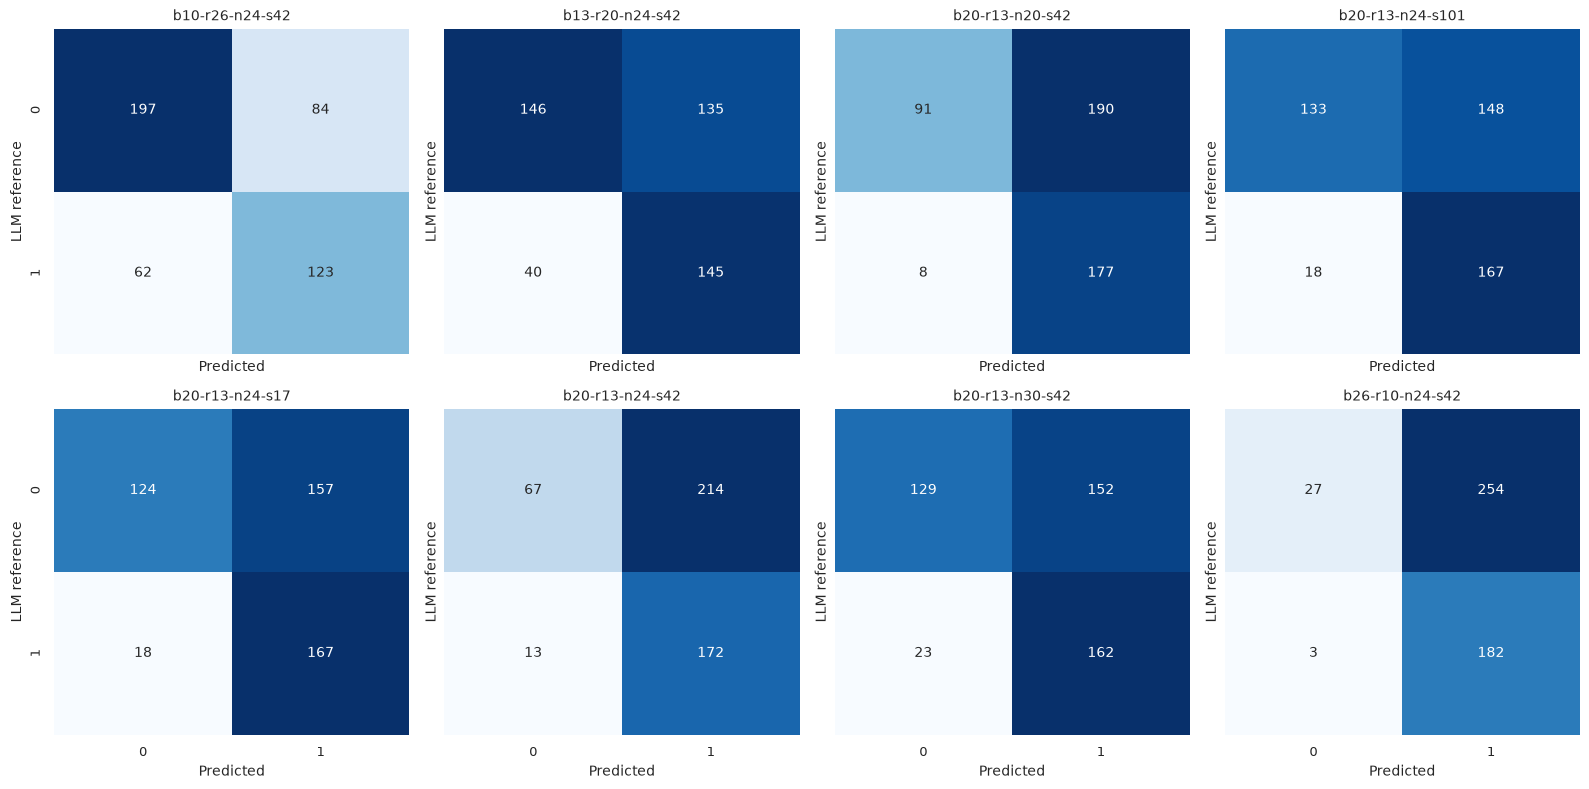

In [6]:
def safe_divide(numerator: int | float, denominator: int | float) -> float:
    return numerator / denominator if denominator else np.nan

def wilson_interval(successes: int, total: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if total == 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    margin = z * math.sqrt(proportion * (1 - proportion) / total + z**2 / (4 * total**2)) / denominator
    return center - margin, center + margin

metric_rows = []
if not predictions.empty:
    decisive_predictions = predictions[predictions["label"].isin(DECISIVE_LABELS)]
    for slug, group in decisive_predictions.groupby("slug", sort=True):
        target = group["target_duplicate"].to_numpy(dtype=bool)
        predicted = group["predicted_duplicate"].to_numpy(dtype=bool)
        tp = int((target & predicted).sum())
        fp = int((~target & predicted).sum())
        tn = int((~target & ~predicted).sum())
        fn = int((target & ~predicted).sum())
        precision = safe_divide(tp, tp + fp)
        recall = safe_divide(tp, tp + fn)
        specificity = safe_divide(tn, tn + fp)
        precision_lower, precision_upper = wilson_interval(tp, tp + fp)
        recall_lower, recall_upper = wilson_interval(tp, tp + fn)
        specificity_lower, specificity_upper = wilson_interval(tn, tn + fp)
        config = configs.set_index("slug").loc[slug]
        metric_rows.append({
            "slug": slug, **config.to_dict(), "evaluated_pairs": len(group),
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "detection_rate": predicted.mean(),
            "precision": precision, "precision_95_lower": precision_lower, "precision_95_upper": precision_upper,
            "recall": recall, "recall_95_lower": recall_lower, "recall_95_upper": recall_upper,
            "specificity": specificity, "specificity_95_lower": specificity_lower, "specificity_95_upper": specificity_upper,
            "f1": safe_divide(2 * precision * recall, precision + recall),
            "balanced_accuracy": np.nanmean([recall, specificity]),
            "mcc": matthews_corrcoef(target, predicted),
        })

metrics = pd.DataFrame(metric_rows)
if not metrics.empty:
    display(metrics[[
        "slug", "tp", "fp", "tn", "fn", "detection_rate", "precision", "recall",
        "specificity", "f1", "balanced_accuracy", "mcc",
    ]])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
    for axis, row in zip(axes.flat, metrics.itertuples(index=False), strict=True):
        matrix = np.asarray([[row.tn, row.fp], [row.fn, row.tp]])
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
        axis.set_title(row.slug.replace("question_choices-", ""))
        axis.set_xlabel("Predicted")
        axis.set_ylabel("LLM reference")
    plt.tight_layout()
    plt.show()

## 6. Paired configuration comparisons

Because every configuration sees the same pairs, prediction agreement and McNemar tests compare treatments without changing the evaluation panel. Holm adjustment controls family-wise error across all pairwise tests.

### Pairwise prediction agreement

slug,question_choices-b10-r26-n24-s42,question_choices-b13-r20-n24-s42,question_choices-b20-r13-n20-s42,question_choices-b20-r13-n24-s101,question_choices-b20-r13-n24-s17,question_choices-b20-r13-n24-s42,question_choices-b20-r13-n30-s42,question_choices-b26-r10-n24-s42
slug,,,,,,,,
question_choices-b10-r26-n24-s42,1.0000,0.8176,0.5880,0.6996,0.6845,0.6159,0.7103,0.5086
question_choices-b13-r20-n24-s42,0.8176,1.0000,0.6416,0.7446,0.7425,0.7425,0.7554,0.6652
question_choices-b20-r13-n20-s42,0.5880,0.6416,1.0000,0.7597,0.7833,0.7275,0.7618,0.7446
question_choices-b20-r13-n24-s101,0.6996,0.7446,0.7597,1.0000,0.8047,0.7704,0.8262,0.7232
question_choices-b20-r13-n24-s17,0.6845,0.7425,0.7833,0.8047,1.0000,0.7597,0.8112,0.7425
question_choices-b20-r13-n24-s42,0.6159,0.7425,0.7275,0.7704,0.7597,1.0000,0.7854,0.8627
question_choices-b20-r13-n30-s42,0.7103,0.7554,0.7618,0.8262,0.8112,0.7854,1.0000,0.7253
question_choices-b26-r10-n24-s42,0.5086,0.6652,0.7446,0.7232,0.7425,0.8627,0.7253,1.0000


### Exact McNemar tests

,left_slug,right_slug,left_correct_only,right_correct_only,discordant,p_value,p_value_holm
21,question_choices-b20-r13-n24-s101,question_choices-b26-r10-n24-s42,110,19,129,0.0000,0.0000
24,question_choices-b20-r13-n24-s17,question_choices-b26-r10-n24-s42,101,19,120,0.0000,0.0000
27,question_choices-b20-r13-n30-s42,question_choices-b26-r10-n24-s42,105,23,128,0.0000,0.0000
6,question_choices-b10-r26-n24-s42,question_choices-b26-r10-n24-s42,170,59,229,0.0000,0.0000
12,question_choices-b13-r20-n24-s42,question_choices-b26-r10-n24-s42,119,37,156,0.0000,0.0000
4,question_choices-b10-r26-n24-s42,question_choices-b20-r13-n24-s42,130,49,179,0.0000,0.0000
19,question_choices-b20-r13-n24-s101,question_choices-b20-r13-n24-s42,84,23,107,0.0000,0.0000
17,question_choices-b20-r13-n20-s42,question_choices-b26-r10-n24-s42,89,30,119,0.0000,0.0000
25,question_choices-b20-r13-n24-s42,question_choices-b20-r13-n30-s42,24,76,100,0.0000,0.0000
22,question_choices-b20-r13-n24-s17,question_choices-b20-r13-n24-s42,82,30,112,0.0000,0.0000


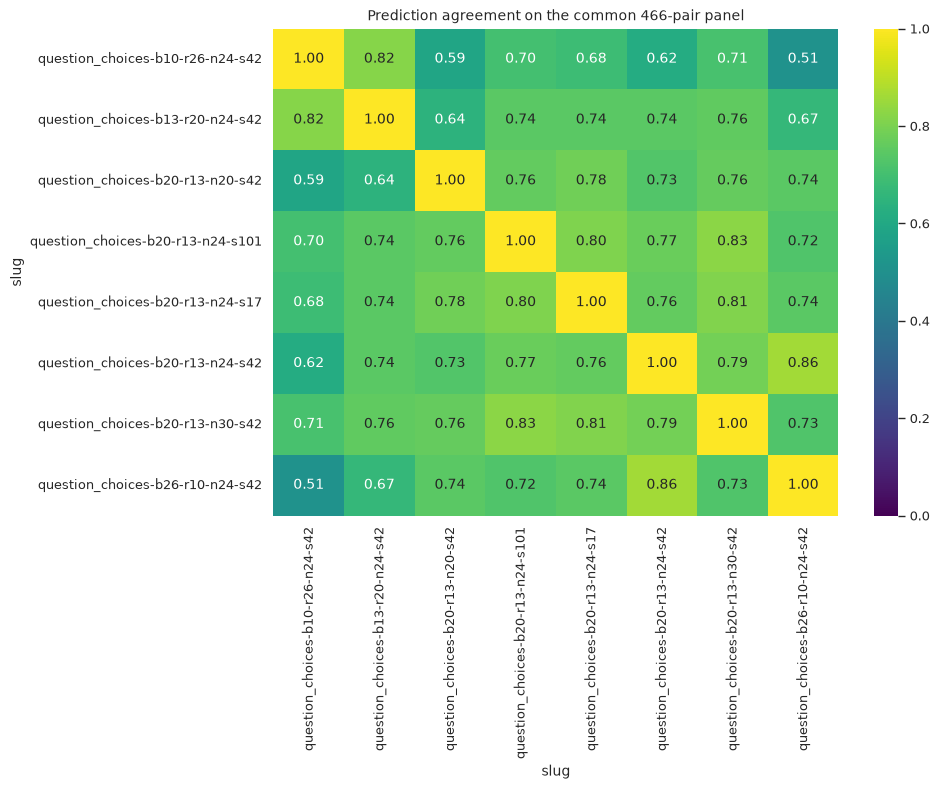

In [7]:
def holm_adjust(p_values: np.ndarray) -> np.ndarray:
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values), dtype=float)
    running_maximum = 0.0
    for rank, index in enumerate(order):
        candidate = min(1.0, (len(p_values) - rank) * p_values[index])
        running_maximum = max(running_maximum, candidate)
        adjusted[index] = running_maximum
    return adjusted

mcnemar_rows = []
if not predictions.empty:
    decisive = predictions[predictions["label"].isin(DECISIVE_LABELS)]
    prediction_matrix = decisive.pivot(index="pair_key", columns="slug", values="predicted_duplicate").astype(bool)
    target = pairs.set_index("pair_key").loc[prediction_matrix.index, "label"].eq("duplicate")
    agreement_matrix = pd.DataFrame(index=prediction_matrix.columns, columns=prediction_matrix.columns, dtype=float)
    for left_slug, right_slug in combinations(prediction_matrix.columns, 2):
        left_error = prediction_matrix[left_slug].ne(target)
        right_error = prediction_matrix[right_slug].ne(target)
        left_correct_only = int((~left_error & right_error).sum())
        right_correct_only = int((left_error & ~right_error).sum())
        discordant = left_correct_only + right_correct_only
        p_value = binomtest(left_correct_only, discordant, p=0.5).pvalue if discordant else 1.0
        mcnemar_rows.append({
            "left_slug": left_slug, "right_slug": right_slug,
            "left_correct_only": left_correct_only, "right_correct_only": right_correct_only,
            "discordant": discordant, "p_value": p_value,
        })
    for left_slug in prediction_matrix.columns:
        for right_slug in prediction_matrix.columns:
            agreement_matrix.loc[left_slug, right_slug] = prediction_matrix[left_slug].eq(prediction_matrix[right_slug]).mean()

mcnemar = pd.DataFrame(mcnemar_rows)
if not mcnemar.empty:
    mcnemar["p_value_holm"] = holm_adjust(mcnemar["p_value"].to_numpy())
    display(Markdown("### Pairwise prediction agreement"), agreement_matrix)
    display(Markdown("### Exact McNemar tests"), mcnemar.sort_values("p_value_holm"))
    plt.figure(figsize=(10, 8))
    sns.heatmap(agreement_matrix.astype(float), vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
    plt.title("Prediction agreement on the common 466-pair panel")
    plt.tight_layout()
    plt.show()

## 7. Banding, n-gram, and seed ablations

The tables below isolate each treatment family while holding the complete-item representation fixed. The precision–recall frontier is descriptive and does not select an operating point.

### Banding

,slug,num_bands,minhashes_per_band,char_ngrams,seed,family,num_hashes,p50_similarity,evaluated_pairs,tp,...,precision_95_upper,recall,recall_95_lower,recall_95_upper,specificity,specificity_95_lower,specificity_95_upper,f1,balanced_accuracy,mcc
0,question_choices-b10-r26-n24-s42,10,26,24,42,banding,260,0.9012,466,123,...,0.6588,0.6649,0.5941,0.7289,0.7011,0.6451,0.7516,0.6276,0.6830,0.3603
1,question_choices-b13-r20-n24-s42,13,20,24,42,banding,260,0.8625,466,145,...,0.5757,0.7838,0.7190,0.8370,0.5196,0.4613,0.5773,0.6237,0.6517,0.3031
5,question_choices-b20-r13-n24-s42,20,13,24,42,banding,260,0.7711,466,172,...,0.4955,0.9297,0.8835,0.9585,0.2384,0.1923,0.2916,0.6025,0.5841,0.2182
7,question_choices-b26-r10-n24-s42,26,10,24,42,banding,260,0.6950,466,182,...,0.4642,0.9838,0.9534,0.9945,0.0961,0.0669,0.1362,0.5862,0.5399,0.1592


### Character n-grams

,slug,num_bands,minhashes_per_band,char_ngrams,seed,family,num_hashes,p50_similarity,evaluated_pairs,tp,...,precision_95_upper,recall,recall_95_lower,recall_95_upper,specificity,specificity_95_lower,specificity_95_upper,f1,balanced_accuracy,mcc
2,question_choices-b20-r13-n20-s42,20,13,20,42,ngram,260,0.7711,466,177,...,0.5333,0.9568,0.9170,0.9779,0.3238,0.2718,0.3806,0.6413,0.6403,0.3356
5,question_choices-b20-r13-n24-s42,20,13,24,42,banding,260,0.7711,466,172,...,0.4955,0.9297,0.8835,0.9585,0.2384,0.1923,0.2916,0.6025,0.5841,0.2182
6,question_choices-b20-r13-n30-s42,20,13,30,42,ngram,260,0.7711,466,162,...,0.5707,0.8757,0.8204,0.9157,0.4591,0.4018,0.5175,0.6493,0.6674,0.3494


### MinHash seeds

,slug,num_bands,minhashes_per_band,char_ngrams,seed,family,num_hashes,p50_similarity,evaluated_pairs,tp,...,precision_95_upper,recall,recall_95_lower,recall_95_upper,specificity,specificity_95_lower,specificity_95_upper,f1,balanced_accuracy,mcc
4,question_choices-b20-r13-n24-s17,20,13,24,17,seed,260,0.7711,466,167,...,0.5693,0.9027,0.8515,0.9376,0.4413,0.3844,0.4997,0.6562,0.6720,0.3656
5,question_choices-b20-r13-n24-s42,20,13,24,42,banding,260,0.7711,466,172,...,0.4955,0.9297,0.8835,0.9585,0.2384,0.1923,0.2916,0.6025,0.5841,0.2182
3,question_choices-b20-r13-n24-s101,20,13,24,101,seed,260,0.7711,466,167,...,0.5846,0.9027,0.8515,0.9376,0.4733,0.4157,0.5317,0.6680,0.6880,0.3931


### Descriptive precision–recall frontier

,slug,precision,recall,f1,mcc
0,question_choices-b10-r26-n24-s42,0.5942,0.6649,0.6276,0.3603
3,question_choices-b20-r13-n24-s101,0.5302,0.9027,0.6680,0.3931
2,question_choices-b20-r13-n20-s42,0.4823,0.9568,0.6413,0.3356
7,question_choices-b26-r10-n24-s42,0.4174,0.9838,0.5862,0.1592


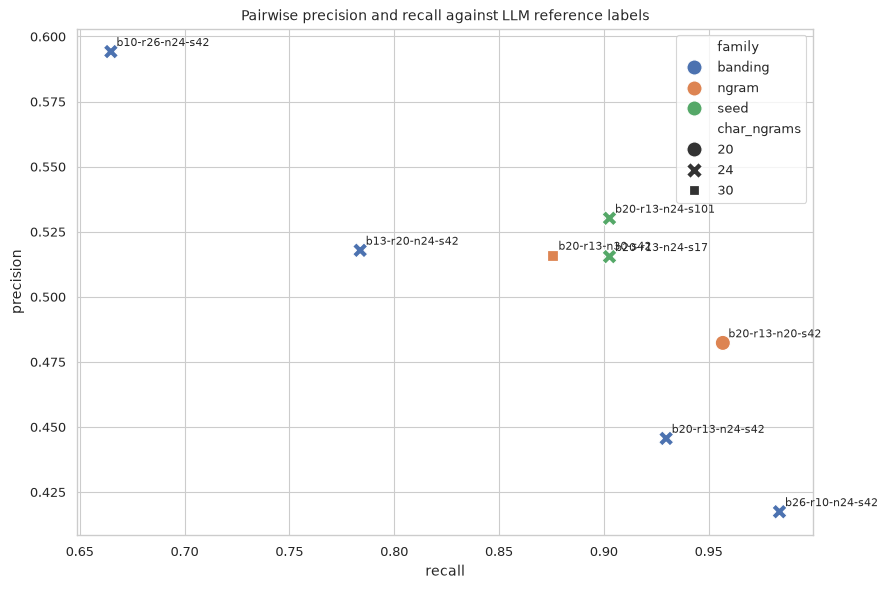

In [8]:
def metric_frontier(frame: pd.DataFrame) -> pd.DataFrame:
    keep = []
    for index, row in frame.iterrows():
        dominated = (
            frame["precision"].ge(row["precision"])
            & frame["recall"].ge(row["recall"])
            & (frame["precision"].gt(row["precision"]) | frame["recall"].gt(row["recall"]))
        ).any()
        if not dominated:
            keep.append(index)
    return frame.loc[keep].sort_values(["recall", "precision"])

if not metrics.empty:
    display(Markdown("### Banding"), metrics[metrics["family"].eq("banding")].sort_values("num_bands"))
    ngram_slugs = configs[configs["num_bands"].eq(20) & configs["seed"].eq(42)]["slug"]
    display(Markdown("### Character n-grams"), metrics[metrics["slug"].isin(ngram_slugs)].sort_values("char_ngrams"))
    seed_slugs = configs[configs["num_bands"].eq(20) & configs["char_ngrams"].eq(24)]["slug"]
    display(Markdown("### MinHash seeds"), metrics[metrics["slug"].isin(seed_slugs)].sort_values("seed"))

    frontier = metric_frontier(metrics)
    display(Markdown("### Descriptive precision–recall frontier"), frontier[["slug", "precision", "recall", "f1", "mcc"]])
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=metrics, x="recall", y="precision", hue="family", style="char_ngrams", s=120)
    for row in metrics.itertuples(index=False):
        plt.annotate(row.slug.replace("question_choices-", ""), (row.recall, row.precision), xytext=(4, 4), textcoords="offset points", fontsize=8)
    plt.title("Pairwise precision and recall against LLM reference labels")
    plt.tight_layout()
    plt.show()

## 8. Lexical diagnostics and deterministic error sample

Exact character-shingle Jaccard and the number of matching bands help explain predictions, but neither is treated as semantic ground truth. The sample exposes up to two false positives and two false negatives per configuration.

In [9]:
error_parts = []
if not predictions.empty:
    decisive = predictions[predictions["label"].isin(DECISIVE_LABELS)].copy()
    for slug, group in decisive.groupby("slug", sort=True):
        false_positive = group[~group["target_duplicate"] & group["predicted_duplicate"]].sort_values(
            ["exact_jaccard", "pair_key"], ascending=[False, True],
        ).head(2).assign(error_type="false_positive")
        false_negative = group[group["target_duplicate"] & ~group["predicted_duplicate"]].sort_values(
            ["exact_jaccard", "pair_key"], ascending=[False, True],
        ).head(2).assign(error_type="false_negative")
        error_parts.extend([false_positive, false_negative])

error_sample = pd.concat(error_parts, ignore_index=True) if error_parts else pd.DataFrame()
if not error_sample.empty:
    text_lookup = pairs.set_index("pair_key")[["left_text", "right_text"]]
    error_sample = error_sample.join(text_lookup, on="pair_key")
    error_sample["left_preview"] = error_sample["left_text"].str.slice(0, 240)
    error_sample["right_preview"] = error_sample["right_text"].str.slice(0, 240)
    display(error_sample[[
        "slug", "error_type", "label", "exact_jaccard", "minhash_similarity",
        "matching_bands", "pair_key", "left_preview", "right_preview",
    ]])

    diagnostic_summary = predictions.groupby(["slug", "target_duplicate", "predicted_duplicate"]).agg(
        pairs=("pair_key", "size"),
        median_jaccard=("exact_jaccard", "median"),
        median_minhash_similarity=("minhash_similarity", "median"),
        mean_matching_bands=("matching_bands", "mean"),
    ).reset_index()
    display(Markdown("### Lexical diagnostics by outcome"), diagnostic_summary)

,slug,error_type,label,exact_jaccard,minhash_similarity,matching_bands,pair_key,left_preview,right_preview
0,question_choices-b10-r26-n24-s42,false_positive,related_but_distinct,0.9750,0.9577,2,4267ce9b803fbd813c16638b2f170633be0f8088cbe2ed83c9bedb690f65342b::55982bcd7a4cd6341687b55ef8fb33eae7a69103dc4db12e018d8561daf556af,"text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in...","text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in..."
1,question_choices-b10-r26-n24-s42,false_positive,related_but_distinct,0.9687,0.9500,2,21e34362e7c48e5dafa29a025018a338375b1214dcb3a81fe4fa356b5a8bb41b::29dc56eb60c43ee9e28dc24d3e8589b320c5f5e48033f4d6059a8933e6f61e5c,"text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in...","text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in..."
2,question_choices-b10-r26-n24-s42,false_negative,duplicate,0.9421,0.9269,0,177ad4578819c17cad5b92dac8961ac0d5c058c27152a9c2bb827f129f5a68c4::cd90851af61fe41f9fd6c03db35a0eac0ad8780dea5ed976db7c6d3647ab5f6e,"formatura exatamente seis membros da comissão de formatura da escola – aldo, bia, chico, dino, eva e fred – vão realizar visitas a empre...","formatura exatamente seis membros da comissão de formatura da escola – aldo, bia, chico, dino, eva e fred – vão realizar visitas a empre..."
3,question_choices-b10-r26-n24-s42,false_negative,duplicate,0.9418,0.9269,0,6ad76ed45a4a9f75d59828740f232930547f4f23cae9679d6e9b932d17b5ee97::96ea30ab8d084c6c06722445d132062cce79497238bfe12ad34e9bf91c040aef,"médico e dentista no período de cinco meses, de janeiro a maio, cada um de três irmãos - aldo, beto e chico – vai ao médico exatamente u...","médico e dentista no período de cinco meses, de janeiro a maio, cada um de três irmãos - aldo, beto e chico – vai ao médico exatamente u..."
4,question_choices-b13-r20-n24-s42,false_positive,related_but_distinct,0.9750,0.9577,6,4267ce9b803fbd813c16638b2f170633be0f8088cbe2ed83c9bedb690f65342b::55982bcd7a4cd6341687b55ef8fb33eae7a69103dc4db12e018d8561daf556af,"text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in...","text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in..."
5,question_choices-b13-r20-n24-s42,false_positive,related_but_distinct,0.9687,0.9500,4,21e34362e7c48e5dafa29a025018a338375b1214dcb3a81fe4fa356b5a8bb41b::29dc56eb60c43ee9e28dc24d3e8589b320c5f5e48033f4d6059a8933e6f61e5c,"text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in...","text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in..."
6,question_choices-b13-r20-n24-s42,false_negative,duplicate,0.8943,0.8846,0,72274d3c53540263e225e3e606bb8ee6a0f8828d878acc5375c13444ce4394a5::8987ebfc688dcb20b8427418a1732cc532a10f22b610aca513d75f74c021cf0f,"a sociedade do século xxi não é mais uma sociedade disciplinar, mas, sim, uma sociedade do desempenho. os seus habitantes também não se ...","a sociedade do século xxi não é mais uma sociedade disciplinar, mas, sim, uma sociedade do desempenho. os seus habitantes também não se ..."
7,question_choices-b13-r20-n24-s42,false_negative,duplicate,0.8914,0.8654,0,138e9993609ed208df555fb4a5e3c937e725129309d21266efbda828c74064bc::6f984089cd016f87478a1770367ca371538dae157c2b4b94d510df23c4184ab3,"almoço para comemorar o aniversário de cláudio, ele e mais quatro amigos – alberto, bruno, dino e eurico foram almoçar juntos no restaur...","almoço para comemorar o aniversário de cláudio, ele e mais qua

### Lexical diagnostics by outcome

,slug,target_duplicate,predicted_duplicate,pairs,median_jaccard,median_minhash_similarity,mean_matching_bands
0,question_choices-b10-r26-n24-s42,False,False,197,0.7386,0.7538,0.0000
1,question_choices-b10-r26-n24-s42,False,True,84,0.8740,0.8865,1.3333
2,question_choices-b10-r26-n24-s42,True,False,62,0.8446,0.8385,0.0000
3,question_choices-b10-r26-n24-s42,True,True,123,0.9401,0.9423,2.5935
4,question_choices-b13-r20-n24-s42,False,False,146,0.7200,0.7269,0.0000
5,question_choices-b13-r20-n24-s42,False,True,135,0.8384,0.8538,1.6889
6,question_choices-b13-r20-n24-s42,True,False,40,0.8288,0.8019,0.0000
7,question_choices-b13-r20-n24-s42,True,True,145,0.9367,0.9346,3.6966
8,question_choices-b20-r13-n20-s42,False,False,91,0.7113,0.7192,0.0000
9,question_choices-b20-r13-n20-s42,False,True,190,0.8172,0.8250,3.0421


## 9. Reproducible artifacts

Predictions, metrics, pairwise tests, signatures, and execution metadata are isolated under the benchmark fingerprint. The annotation file remains read-only.

In [10]:
if not predictions.empty and not metrics.empty:
    ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
    predictions.sort_values(["slug", "pair_key"]).to_parquet(PREDICTIONS_PATH, index=False)
    metrics.sort_values("slug").to_csv(METRICS_PATH, index=False)
    mcnemar.sort_values(["left_slug", "right_slug"]).to_csv(MCNEMAR_PATH, index=False)
    metadata = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "benchmark_fingerprint": benchmark_fingerprint,
        "annotation_path": str(ANNOTATION_PATH),
        "annotation_sha256": annotation_sha256,
        "python_version": platform.python_version(),
        "nemo_curator_version": importlib.metadata.version("nemo-curator"),
        "cuda_visible_devices": os.environ["CUDA_VISIBLE_DEVICES"],
        "gpu_description": GPU_DESCRIPTION,
        "pairs": len(pairs),
        "unique_complete_items": int(all_texts.nunique()),
        "num_hashes": NUM_HASHES,
        "use_64_bit_hash": False,
        "configurations": configs.to_dict(orient="records"),
        "signature_specs": signature_specs.to_dict(orient="records"),
    }
    METADATA_PATH.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

    persisted_predictions = pd.read_parquet(PREDICTIONS_PATH).sort_values(["slug", "pair_key"]).reset_index(drop=True)
    expected_predictions = predictions.sort_values(["slug", "pair_key"]).reset_index(drop=True)
    pd.testing.assert_frame_equal(persisted_predictions, expected_predictions)
    for spec in signature_specs.itertuples(index=False):
        key = (int(spec.char_ngrams), int(spec.seed))
        persisted = validate_signatures(np.load(signature_path(*key), allow_pickle=False), signature_path(*key))
        if not np.array_equal(persisted, signature_cache[key]):
            raise ValueError(f"Persisted signature cache changed for {key}.")

    artifact_summary = pd.Series({
        "signature caches": len(list(SIGNATURE_DIR.glob("*.npy"))),
        "predictions": len(persisted_predictions),
        "metric rows": len(metrics),
        "McNemar comparisons": len(mcnemar),
        "artifact root": str(ARTIFACT_ROOT),
    }, name="value")
    display(artifact_summary.to_frame())

,value
signature caches,5
predictions,3728
metric rows,8
McNemar comparisons,28
artifact root,/home/aluno_paulosantana/repositories/mmlu-pt/output/fuzzy-deduplication-pairwise-benchmark/79482abe9e4b


## 10. Interpretation boundaries

- The 466 pairs form a fixed, fuzzy-candidate-enriched benchmark rather than a random sample of all possible corpus pairs.
- Human–LLM agreement supports the operational reference labels but does not make them universal ground truth.
- LSH is probabilistic; seed treatments expose only part of its variation.
- Direct band collision measures pairwise candidate generation. It intentionally excludes connected-component chaining and representative selection.
- Statistical intervals do not correct for the original candidate-selection mechanism.
- The decision below is therefore an operational choice for this corpus and cost model, not a universal similarity threshold.

## 11. Operational decision and rationale

**Verdict: use `question_choices-b10-r26-n24-s42` as the conservative candidate-generation configuration. Do not use its output for unreviewed automatic deletion.**

The selected operating point uses the complete MCQA item (`question + choices`), 10 bands, 26 MinHashes per band, character 24-grams, seed 42, and 260 32-bit hashes. It is the most defensible configuration when a false positive—removing a valid, semantically distinct question—is more costly than leaving some redundancy in the corpus.

**Controlled banding comparison (character 24-grams and seed 42 held fixed)**

| Metric | `b10-r26-n24-s42` | `b20-r13-n24-s42` |
|---|---:|---:|
| Precision | **59.4%** | 44.6% |
| Recall | 66.5% | **93.0%** |
| False positives | **84** | 214 |
| False negatives | 62 | **13** |
| Specificity | **70.1%** | 23.8% |
| F1 | **62.8%** | 60.2% |

On the 466-pair benchmark, the selected configuration achieved the highest precision (59.4%; Wilson 95% CI: 52.6%–65.9%), the highest specificity (70.1%), and the fewest false positives (84), with 66.5% recall, 62 false negatives, and 68.7% raw accuracy. Holding representation, character n-grams, and seed fixed, changing only the banding to `b20-r13` increased recall to 93.0% but reduced precision to 44.6% and produced 214 false positives. Their paired correctness difference is significant after Holm correction (`p_adj = 2.70e-8`). This controlled comparison supports the conservative `b10-r26` banding when false positives are more costly than residual redundancy.

As an exploratory sensitivity result, `question_choices-b20-r13-n24-s101` maximized F1 (66.8%), balanced accuracy (68.8%), and MCC (0.393), with 90.3% recall and 148 false positives. It is not the controlled comparator for the banding decision because both banding and seed differ from the selected configuration. Moreover, the paired McNemar comparison does not show a statistically significant overall-accuracy advantage for this seed-101 treatment over the selected treatment after Holm correction (`p_adj = 0.756`). Selecting seed 101 solely from this benchmark would risk tuning a stochastic parameter to the evaluation set; the observed disagreement across seeds instead supports treating seed variation as a robustness analysis and retaining the pre-specified seed 42.

The companion [corpus-level ablation](fuzzy_deduplication_ablation.ipynb) provides a consistent operational picture. On 39,120 records, the selected configuration flagged 985 documents (2.52%), formed 487 components with a largest component of 26 items, and had 98.08% of audited edges at exact Jaccard $\geq 0.8$. It also produced a maximum examination-share shift of 0.626 percentage points and completed in approximately 61 seconds. These measurements favor a smaller, lexically stronger, and less distribution-distorting candidate set.

This is **not evidence for blind removal**. Even the selected configuration's precision is insufficient for irreversible automatic deletion, the benchmark is enriched with fuzzy candidates rather than sampled randomly from the corpus, and connected-component chaining can propagate pairwise mistakes. The recommended procedure is therefore: generate candidates with `question_choices-b10-r26-n24-s42`, validate candidate pairs or components semantically, and then retain a representative using a deterministic completeness policy with stable-ID tie-breaking. The benchmark metrics supporting this decision are stored in [`metrics.csv`](../output/fuzzy-deduplication-pairwise-benchmark/79482abe9e4b/metrics.csv).